In [14]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

In [15]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/DATASETS/airline-passengers.csv')

In [16]:
df['Month'] = pd.to_datetime(df['Month'], format = 'mixed')
df = df.sort_values('Month')
df = df.set_index('Month')

In [17]:
df.drop_duplicates(inplace= True)

In [18]:
def time(df):
    df['month'] = df.index.month
    df['Year'] = df.index.year
    df['Quarter'] = df.index.quarter
    return df

def features(df):
    df['Lag 1'] = df['Passengers'].shift(1)
    df['Lag 6'] = df['Passengers'].shift(6)
    df['Lag 12'] = df['Passengers'].shift(12)
    df['MA 6'] = df['Passengers'].shift(1).rolling(6).mean()
    df['MA 12'] = df['Passengers'].shift(1).rolling(12).mean()
    df['STD 6'] = df['Passengers'].shift(1).rolling(6).std()
    df['STD 12'] = df['Passengers'].shift(1).rolling(12).std()
    return df



In [19]:
train = df[(df.index >= '1949-01-01') & (df.index < '1955-01-01')]
val = df[(df.index >= '1955-01-01') & (df.index < '1958-01-01')]
test = df[(df.index >= '1958-01-01') & (df.index < '1960-12-01')]

In [20]:
train = time(train)
train = features(train)

val = time(val)
val = features(val)

test = time(test)
test = features(test)

train.dropna(inplace= True)
val.dropna(inplace=True)
test.dropna(inplace= True)

In [22]:
Features = ['Lag 1', 'Lag 12', 'Lag 6', 'MA 6', 'MA 12', 'STD 6', 'STD 12', 'month', 'Year', 'Quarter']
Target = ['Passengers']

In [23]:
x_train = train.drop('Passengers',axis = 1)
y_train = train['Passengers']

x_val = val.drop('Passengers',axis = 1)
y_val = val['Passengers']

x_test = test.drop('Passengers',axis = 1)
y_test = test['Passengers']

In [24]:
model = XGBRegressor(n_estimators = 500, learning_rate = 0.005, max_depth = 5)

In [27]:

def validate(model, x_train, y_train, x_test, y_test):

    history_x = x_train.copy()
    history_y = y_train.copy()
    
    predictions = []
    
    for i in range(len(x_test)):
        model.fit(history_x, history_y)

        pred = model.predict(x_test.iloc[[i]])

        predictions.append(pred[0])

        history_x = pd.concat([x_train, x_test.iloc[[i]]])

        history_y = pd.concat([y_train, y_test.iloc[[i]]])

    error = mean_absolute_error(y_test, predictions)

    residuals = y_test.values - predictions
    
    return error, predictions, residuals

In [28]:
mae, predictions, residuals = validate(model, x_train, y_train, x_test, y_test)

In [29]:
print (mae)

123.4753770828247


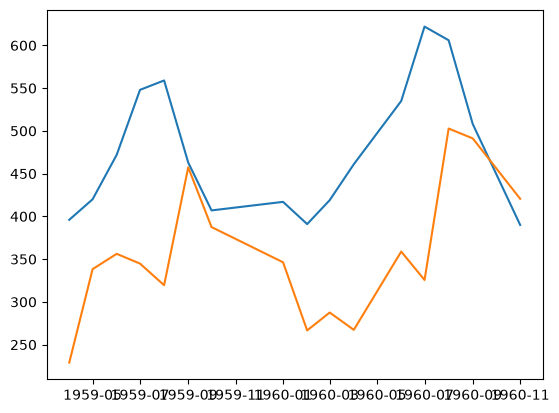

In [35]:
import matplotlib.pyplot as plt

plt.plot(y_test)
plt.plot(test.index, predictions)

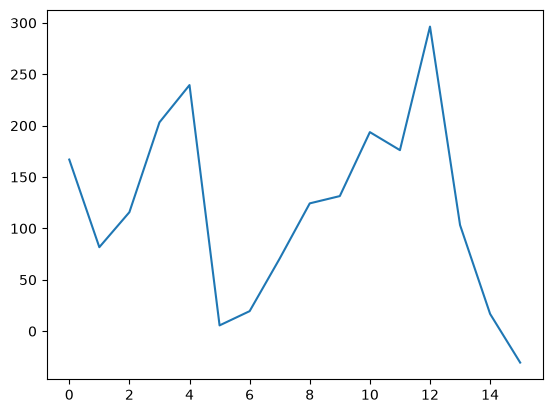

In [32]:
plt.plot(residuals)

In [33]:
residuals.mean()

np.float64(119.65375232696533)